# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("/workspaces/ds-fall-2026/Week-05-Business-Stats-Analytics/data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
##df.duplicated().sum()
#720
# df.value_counts()
# #multiple cars are 2000 msrp.
# print(df['MSRP'].describe()) 

# print(df['MSRP'].value_counts())
# #1036 cars being exactly 2000 is a wierd
# print(df[df['MSRP'] == 2000][['Make', 'Model', 'Year']])
# print(df.max())
# print(df.min())
# print(df["highway MPG"].max())
# high_mpg = df[df['highway MPG'] > 100]
# print(high_mpg[['Make', 'Model', 'Engine Fuel Type', 'highway MPG']])

print(df["Engine Cylinders"].min())
zero_cylinders = df[df['Engine Cylinders'].isnull()]
print(zero_cylinders[['Make', 'Model', 'Engine Fuel Type', 'Engine Cylinders']])

# print(df['Transmission Type'].value_counts())

print(df.isnull().sum())


## no matter the car the only thing that is consistent is that its only old cars
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

0.0
            Make    Model             Engine Fuel Type  Engine Cylinders
1983   Chevrolet  Bolt EV                     electric               NaN
1984   Chevrolet  Bolt EV                     electric               NaN
3716  Volkswagen   e-Golf                     electric               NaN
3717  Volkswagen   e-Golf                     electric               NaN
3718  Volkswagen   e-Golf                     electric               NaN
3719  Volkswagen   e-Golf                     electric               NaN
5778  Mitsubishi   i-MiEV                     electric               NaN
5779  Mitsubishi   i-MiEV                     electric               NaN
5780  Mitsubishi   i-MiEV                     electric               NaN
8373      Toyota  RAV4 EV                     electric               NaN
8695       Mazda     RX-7             regular unleaded               NaN
8696       Mazda     RX-7             regular unleaded               NaN
8697       Mazda     RX-7             regular u

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 |Cars that are old, before the year 2000 are all listed at 2000 dollars, even though many of them are different modelt types and should range in value. | I found this by look at the describe breakdown and saw that multiple cars had msrps of 2000, which made me dig deeper with a value count for msrp | 1036 | I set these MSRP values to Nan| The 2000 value for MSRP seems to be a placeholder for older cars that are missing this MSRP data, keeping the 2000 dollars would greatly skew the average MSRP metrics and data, making these cars look much cheaper on average.|
| 2 | There is a gas engine Audi A6 with 354 MPG | I found it when looking at the max values in the dataset, I then looked at the vehicles and their fuel types with MPG's above 100 and found this Audi with an impossible MPG | 1 | Set this highway MPG to NaN| Leaving this absurd MPG would skew the data and create outliers that can manipulate the mean and median.|
| 3 | There are cars with NaN cylinders| I found this when i checked the null counts for all categories and found 30 NaN values for engine types, which was weird as I saw that Electric cars where listed with 0 cylinders. I checked these Nan Values and found that these are all electric vehicles and they should have 0's instead of NaN | 30 | I filled in these null values with 0's for electric vehicles only, the mazda rotary engines do not have cylinders so it is better to leave those as null| It is not good practice to have some electric vehicles have values such as 0 and some with null values, when you are referring to the same thing, it is better to keep them uniform.|
| 4 | There are cars with missing door counts | I checked the categories for their null counts and found 6 missing values for doors| 6 | I Inputted the data manually for the 6 vehicles, it consisted of teslas that have 4 doors and a ferrari that has one| I did this because these are vehicles that are high in value and have good data but are just missing door counts that are easily accessible, this can lead to better data. |
| 5 | There is a Transmission type written as Unknown| I saw this when i did the .max function, I then did a value count for Transmission types| 19| Replaced the string unknown with NaN| Unknown is a string placeholder and pandas will treat it as an acutally transmission type and can mess with the data analysis later. |

In [4]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names
clean.loc[clean['engine_fuel_type'] == 'electric','engine_cylinders'] = clean.loc[clean['engine_fuel_type'] == 'electric', 'engine_cylinders'].fillna(0.0)
clean.loc[clean['transmission_type'] == 'UNKNOWN','transmission_type'] = np.nan
clean.loc[clean['msrp'] == 2000,'msrp'] = np.nan
clean.loc[clean['highway_mpg'] == 354, 'highway_mpg'] = np.nan
clean.loc[(clean['make'] == 'Tesla') & (clean['model'] == 'Model S'),'number_of_doors'] = 4
clean.loc[(clean['make'] == 'Ferrari') & (clean['model'] == 'FF'),'number_of_doors'] = 2



In [5]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])

# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11914, 15)
engine_fuel_type        3
engine_hp              69
engine_cylinders       20
transmission_type      19
highway_mpg             1
msrp                 1036
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

44270.42627321199
31602.5


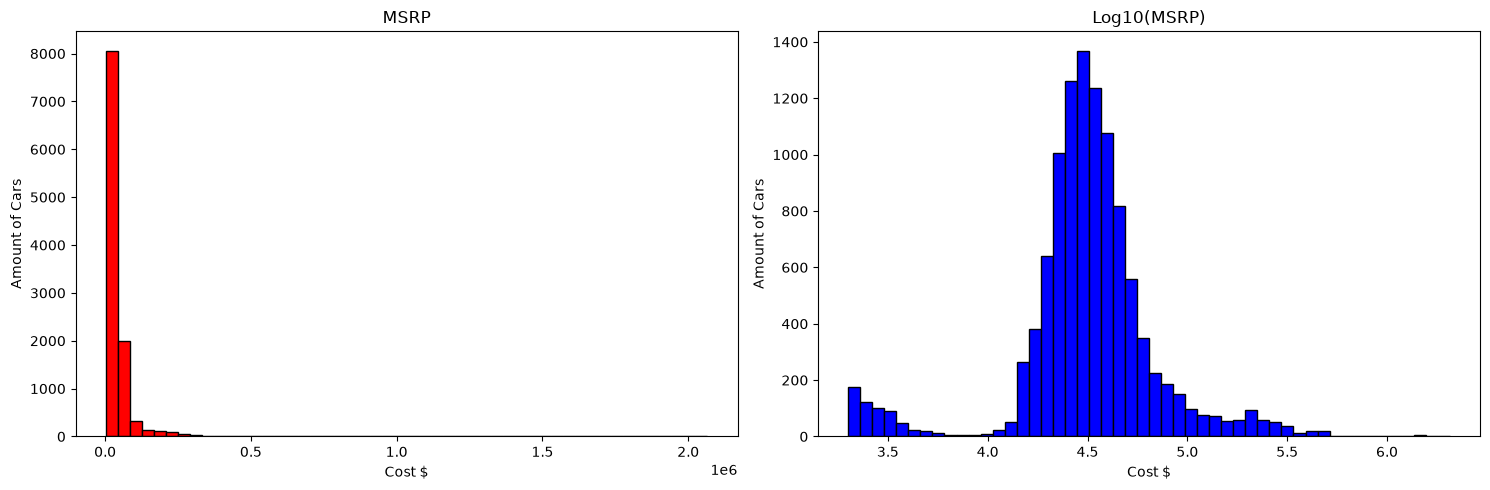

24.40


In [6]:
# a) mean and median
mean_MSRP = clean['msrp'].mean()
print(mean_MSRP)
median_MSRP = clean['msrp'].median()
print(median_MSRP)

# The Mean is larger than the median because although the median shows that there
# is a higher count of affordable cars, the higher value of the expensive cars 
# being much greater than the affordable cars make the mean larger while the median is smaller.

# b) two histograms side by side (plt.subplots(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].hist(clean['msrp'].dropna(), bins=50, color='red', edgecolor='black')
axes[0].set_title('MSRP')
axes[0].set_xlabel('Cost $')
axes[0].set_ylabel('Amount of Cars')

axes[1].hist(np.log10(clean['msrp'].dropna()), bins=50, color='blue', edgecolor='black')
axes[1].set_title('Log10(MSRP)')
axes[1].set_xlabel('Cost $')
axes[1].set_ylabel('Amount of Cars')

plt.tight_layout()
plt.show()

#The x axis is so wide because of the one bugatti veyron which costs 2 million
# c) share of cars above the mean
total_MSRP = clean['msrp'].notna().sum()
cars_above_mean = (clean['msrp']>mean_MSRP).sum()
percent_above = (cars_above_mean/total_MSRP) * 100

print(f"{percent_above:.2f}")
#I had to look this up.

# The Median number belongs on the homepage becuase the mean is heavily distorted 
# by the small amount of the exceedingly expensive vehicles such as the bugatti. 
# Which means that saying the average car costs around 44,270 is not true since
# roughly 75% cars cost less than the mean. Making the customer think the 
# average car is more expensive than it really is.

**Answer:** The Median number belongs on the homepage becuase the mean is heavily distorted  by the small amount of the exceedingly expensive vehicles such as the bugatti. Which means that saying the average car costs around 44,270 is not true since roughly 75% cars cost less than the mean. Making the customer think the average car is more expensive than it really is.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [7]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
df_2017 = clean[clean['year'] == 2017]

stats = df_2017.groupby('vehicle_size')['highway_mpg'].agg(['mean','std'])
print(stats)

compact_mean = stats.loc['Compact','mean']
compact_std = stats.loc['Compact','std']
# print(f"{compact_mean}, {compact_std}")

large_mean = stats.loc['Large','mean']
large_std = stats.loc['Large','std']
# print(f"{large_mean}, {large_std}")

# b) z = (value - class mean) / class std
civic_z_score = (42 - compact_mean)/compact_std
volvo_z_score = (34 - large_mean)/large_std

print(f"{civic_z_score:.2f}, {volvo_z_score:.2f}")


                   mean        std
vehicle_size                      
Compact       31.833333  10.697106
Large         22.943158   3.502099
Midsize       29.507599   5.449709
0.95, 3.16


**Answer:** The Volvo S90 is much more impressive for its Large Class, in comparison to the Civic in the sedan class. The Z score of .95 for the civic means that is within one standard deviation above the average compact car mean while the Volvos S90 z score of 3.16 means that it is roughly 3 standard deviations from the above the average large car making it an outlier and very efficient for its class.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

36647.5
[37070.  36807.5 36065.  ... 36850.  36150.  36905. ]
35870.0  37635.0


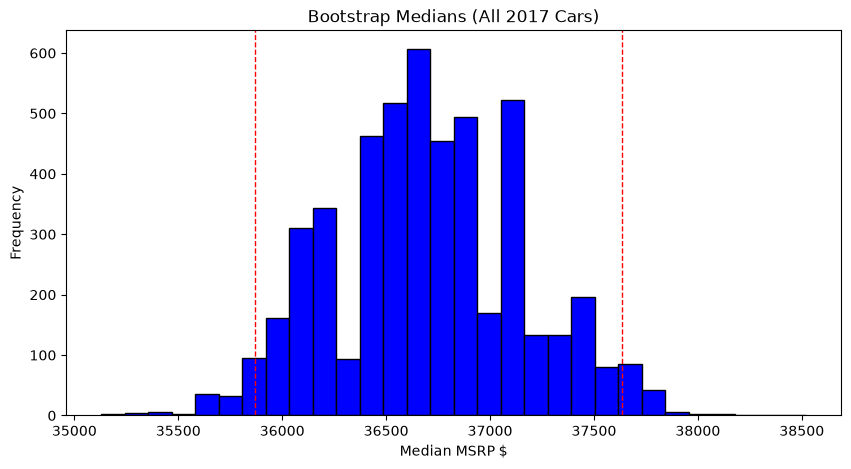

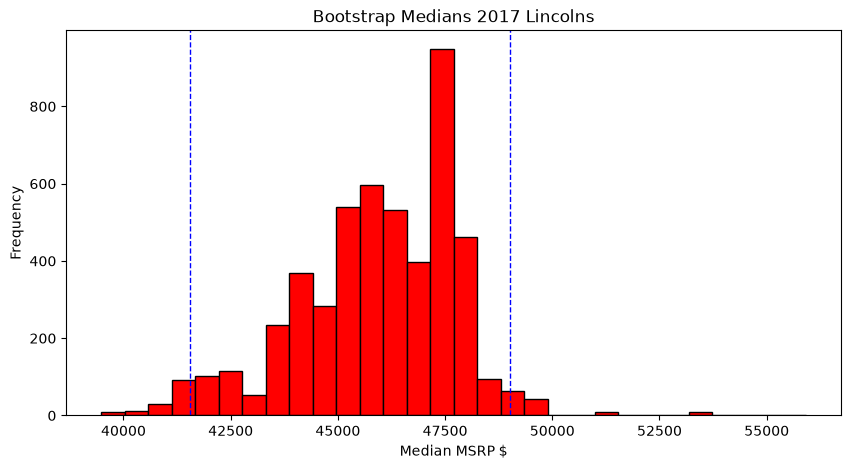

In [ ]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    return np.median(samples,axis=1)

# a, b)
cars_2017 = clean[(clean['year'] ==2017) &  clean['msrp'].notna()]
# print(cars_2017)
msrp_2017 = cars_2017['msrp'].values
median_2017 = np.median(msrp_2017)
print(median_2017)

boot_medians_all = bootstrap_median(msrp_2017)
print(boot_medians_all)
ci_all = np.percentile(boot_medians_all, [2.5, 97.5])
print(f"{ci_all[0]}  {ci_all[1]}")

plt.figure(figsize=(10, 5))
plt.hist(boot_medians_all, bins=30, color='blue', edgecolor='black')
plt.title('Bootstrap Medians (All 2017 Cars)')

plt.axvline(ci_all[0], color='red', linestyle='dashed', linewidth=1)
plt.axvline(ci_all[1], color='red', linestyle='dashed', linewidth=1)

plt.xlabel('Median MSRP $')
plt.ylabel('Frequency')
plt.show()

# c)
target_make = 'Lincoln'
prices_make = cars_2017[cars_2017['make'] == target_make]['msrp'].values

boot_medians_make = bootstrap_median(prices_make)
ci_linc = np.percentile(boot_medians_make, [2.5, 97.5])

plt.figure(figsize=(10, 5))
plt.hist(boot_medians_make, bins=30, color='red', edgecolor='black')
plt.title(f'Bootstrap Medians 2017 Lincolns')

plt.axvline(ci_linc[0], color='blue', linestyle='dashed', linewidth=1)
plt.axvline(ci_linc[1], color='blue', linestyle='dashed', linewidth=1)

plt.xlabel('Median MSRP $')
plt.ylabel('Frequency')
plt.show()




**Answer:** Based on the data with 95% confidence that the true median car price for all 2017 cars falls between 35870 and 37635 Dollars.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

In [43]:
import scipy.stats as stats

# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compacts_2017 = clean[(clean['year'] == 2017) & (clean['vehicle_size'] == 'Compact') & clean['highway_mpg'].notna()]
mpg_data = compacts_2017['highway_mpg']
print(len(mpg_data))

# c) one-sample t-test vs 30
t_stat, p_val = stats.ttest_1samp(mpg_data, popmean=30, alternative='greater')
print(f"one sample t test: {t_stat:.2f}, {p_val:.8f}")
# d) rows per make+model, then one row per model and retest
model_avg = compacts_2017.groupby(['make','model'])['highway_mpg'].mean()
print(f"make + model rows: {len(model_avg)}")
t_stat_ind, p_val_ind = stats.ttest_1samp(model_avg, popmean=30, alternative='greater')
print(f"one sample t test for averaged data: {t_stat_ind:.2f}, {p_val_ind:.8f}")

534
one sample t test: 3.96, 0.00004248
make + model rows: 90
one sample t test for averaged data: 3.10, 0.00131067


**Answer:** 
a. 
H0: The true mean highway MPG for 2017 compact vehicles is less than 30MPG. 

Ha: The true mean highway MPG for 2017 compact vehicles is greater than 30MPG.

This is one Sided because we are testing if the average is greater than 30, meaning that if the cars average exactly 30 or less than 30MPG we cant make this claim.

b. the sample size is 534,  this distribution is right skewed with most cars being around 25 to 35 mpg, then there are the hybrid/EV's that are 100 MPG. The t test is reasonable because according to the central limit theorem if the sample size is large enough the sampling distribution will be approximately normal, since the sample is large in comparison to 30 it is fair to do the t test. 

c. When we run the t test at .05 the t stat is 3.96 and the p value is .000042. Since the p value is much smaller than the .05 we ran the test at we have sufficient evidence that the average highway MPG for 2017 compact cars is greater than 30. Marketing will be able to comfortably make this claim.

d. When using the averaged data the t test the t stat is 3.1 and the p value is .0013. The total rows here dropped significantly from 534 to 90. This is because some vehicles have many more duplicates which could skew the test. I trust this test more, because the MPG will be roughly the same for duplicates of the same model, so testing just the car models we have a more accurate test with less chances to skew it. 

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [55]:
# a) compare median MSRP by transmission type
auto_manual = clean[clean['transmission_type'].isin(['AUTOMATIC','MANUAL'])]
print(auto_manual.groupby('transmission_type')['msrp'].median())


# b) compare year by transmission type
print(auto_manual.groupby('transmission_type')['year'].median())
# c) compare 2015-2017 medians overall and within each vehicle_size
new_cars = auto_manual[(auto_manual['year'] >= 2015) & (auto_manual['year'] <= 2017)]
#Overall
print(new_cars.groupby('transmission_type')['msrp'].median())
#By size
print(new_cars.groupby(['vehicle_size', 'transmission_type'])['msrp'].median())

# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
new_compacts = new_cars[new_cars['vehicle_size'] == 'Compact']
auto_prices = new_compacts[new_compacts['transmission_type'] == 'AUTOMATIC']['msrp'].dropna()
manual_prices = new_compacts[new_compacts['transmission_type'] == 'MANUAL']['msrp'].dropna()

u_stat, p_val = stats.mannwhitneyu(auto_prices, manual_prices, alternative='two-sided')

print(f"auto median: {auto_prices.median()}")
print(f"manual median: {manual_prices.median()}")
print(u_stat, p_val)



transmission_type
AUTOMATIC    33360.0
MANUAL       22270.0
Name: msrp, dtype: float64
transmission_type
AUTOMATIC    2015.0
MANUAL       2008.0
Name: year, dtype: float64
transmission_type
AUTOMATIC    36732.5
MANUAL       27090.0
Name: msrp, dtype: float64
vehicle_size  transmission_type
Compact       AUTOMATIC            25990.0
              MANUAL               26255.0
Large         AUTOMATIC            44540.0
              MANUAL               38395.0
Midsize       AUTOMATIC            37605.0
              MANUAL               26920.0
Name: msrp, dtype: float64
auto median: 25990.0
manual median: 26255.0
346203.0 0.0941621665794619


**Answer:**

A. with general data on average manual cars are cheaper than automatic cars

B. What I noticed is that most manual cars are older than the newer cars 

c. What the medians suggest is that you will find on average that the modern manual compacts on average cost a little more or are pretty much the same price as their automatic counterparts. But when it comes to the p value, since it is above .05 then ther eis not statistically significant evidence that manuals are cheaper in this case. 

d. While overall manual cars may look cheaper that is because the majority of manual cars are older than our automatic cars, when we compare modern compact automatics to modern compact manuals there is not significant evidence proving that manuals are cheaper than automatics. 

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [87]:
# a) Welch t-test, 4-door vs 2-door
doors = clean[(clean['number_of_doors'].isin([2.0, 4.0])) & clean['highway_mpg'].notna()]

doors4 = doors[doors['number_of_doors'] == 4.0]['highway_mpg'].values
doors2 = doors[doors['number_of_doors'] == 2.0]['highway_mpg'].values

t_stat, p_val = stats.ttest_ind(doors4, doors2, equal_var=False)

print(f"four door mean: {doors4.mean():.2f}")
print(f"two door mean: {doors2.mean():.2f}")
print(f"difference between means: {doors4.mean() - doors2.mean():.2f}")
print(f"p value: {p_val}")

# b) yearly gas cost = miles * price_per_gallon / mpg
mean4 = doors4.mean()
mean2 = doors2.mean()

miles = 12000
gas = 3.5
gas_saved4 = miles/mean4 * gas
gas_saved2 = miles/mean2 * gas
savings = gas_saved2 - gas_saved4
print(f"{savings:.2f}")




# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    sample4 = rng.choice(doors4, 30, replace=False)
    sample2 = rng.choice(doors2, 30, replace=False)

    stat_sim, pval_sim = stats.ttest_ind(sample4, sample2, equal_var=False)

    if pval_sim < 0.05:
        hits += 1

    pass
print(f"Fraction of tests above .05: {hits / n_sims}")

four door mean: 27.44
two door mean: 25.35
difference between means: 2.09
p value: 1.5775721673901396e-43
126.04
Fraction of tests above .05: 0.155


**Answer:**

A. 
four door mean: 27.44
two door mean: 25.35
difference between means: 2.09
p value: 1.5775721673901396e-43

B.
$126.04 in savings a year.

C. 
15.5 Percent of the sample tests are significant.

D. I would not put "4 door cars are significantly more fuel efficient because although, it may show as significant, although it is true, there is only roughly 10 dollar difference in gas spending per month. What i would Say instead is talk about how 4 door cars offer more space while not sacrificing much on highway MPG.

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**

Although when looking at our initial data, it says that manual vehicles are cheaper, this is not the entire truth as we need to bring into consideration that a lot of the manual cars are older models in comparison to the Automatic vehicles, When we compared our more modern vehicles from the years 2015 - 2017, we found that the price difference is negligable, if not more expensive for manual compact vehicles. I believe that instead we should market that our typical car price is "31602.5" instead of the mean price as that is roughly $44270 and is skewed by our more expensive vehicles. Multi million dollar vehicles such as the bugatti does not represent our core inventory. Also a limitation of our dataset is the fact that it lists cars with minor trim variations as seperate cars, which can skew certain metrics such as MPG or Engine Cylinders. 

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [12]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [13]:
# S2